# age 결측 데이터 치환 해주세요

In [49]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# 타이타닉 데이터 불러오기
df = sns.load_dataset("titanic")

# 변경 전 데이터 저장
df_before = df.copy(deep=True)
print(f"before : {df.shape}")


before : (891, 15)


In [50]:
bins = [0,10,20,30,40,50,60,70,80]
# age들을 묶을 카테고리 설정
labels = ["0-10","10-20","20-30","30-40","40-50","50-60","60-70","70-80"]

# age_group 이라는 이름을 추가해서 나이대별을 10씩 묶음 EX) 13 -> 10-20 / 23->20-30 
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

# df_group이라는 데이터 프레임으로 복사 후 저장
df_group = df[["who","age_group","survived"]].copy()

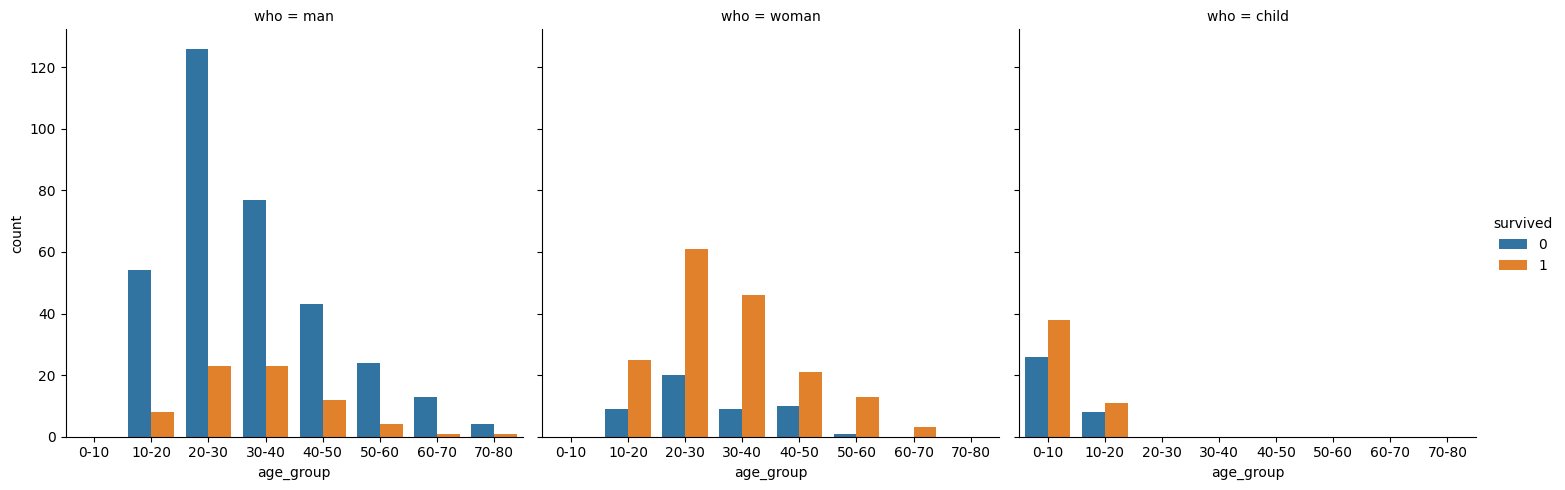

In [51]:
# x축을 age_group으로 y축을 count로 그리고 who의 카테고리["man", "woman", "child"] 별로 나누고 각 그래프별로 survived의 0,1을 다른 막대 그래프로 표현함
g = sns.catplot(
    data=df,
    x="age_group",
    hue="survived",
    col="who",
    kind="count"
)

# 그래프 보여주기
plt.show()

# man, woman, child의 나잇대별 count와 survive의 0,1로 나눠서 전반적으로 비율을 시각화함
# 결측치를 분배할 수 있는 비율을 시각화함

In [52]:
# 위 그래프에 대한 각각의 비율을 저장한 데이터프레임을 제작
# who의 카테고리를 큰 기준으로 age_group로 구분하고 survived를 통해서 세부적인 비율을 알아냄
ratio_df = (
    df_group
    .groupby(["who","age_group"])["survived"]
    .value_counts(normalize=True)
    .rename("ratio")
    .reset_index()
)
ratio_df

,who,age_group,survived,ratio
0,child,0-10,1,0.593750
1,child,0-10,0,0.406250
2,child,10-20,1,0.578947
3,child,10-20,0,0.421053
4,man,10-20,0,0.870968
5,man,10-20,1,0.129032
6,man,20-30,0,0.845638
7,man,20-30,1,0.154362
8,man,30-40,0,0.770000
9,man,30-40,1,0.230000


In [53]:
# 원본 데이터에서 "age"의 값들이 NaN인 데이터들만 모아둔 데이터프레임을 만들음
age_null = df[df["age"].isna()]

# 그리고 who를 첫번째 기준으로 survived를 두번째 기준으로 분류함
age_null.groupby(["who", "survived"])

In [54]:
# for문을 통해서 who와 survived에 값과 동일한  group들을 시각화할 수 있게 보여줌
for (who, survived), group in age_null.groupby(["who", "survived"]):
    print(f"\nwho = {who}, survived = {survived}")
    print(group)


who = man, survived = 0
     survived  pclass   sex  age  sibsp  parch     fare embarked  class  who  \
5           0       3  male  NaN      0      0   8.4583        Q  Third  man   
26          0       3  male  NaN      0      0   7.2250        C  Third  man   
29          0       3  male  NaN      0      0   7.8958        S  Third  man   
42          0       3  male  NaN      0      0   7.8958        C  Third  man   
45          0       3  male  NaN      0      0   8.0500        S  Third  man   
..        ...     ...   ...  ...    ...    ...      ...      ...    ...  ...   
837         0       3  male  NaN      0      0   8.0500        S  Third  man   
846         0       3  male  NaN      8      2  69.5500        S  Third  man   
859         0       3  male  NaN      0      0   7.2292        C  Third  man   
868         0       3  male  NaN      0      0   9.5000        S  Third  man   
878         0       3  male  NaN      0      0   7.8958        S  Third  man   

     adult_mal

In [55]:
# 그리고 한번 더 groupby로 묶어서 각각의 값에 대한 갯수를 확인함
# child의 age에 NaN 값이 없기 때문에 child값은 없음
age_null.groupby(["who","survived"]).size()

who    survived
man    0           108
       1            16
woman  0            17
       1            36
dtype: int64

In [56]:
# index에 조건을 넣기 위해서 변수를 둠
# man일대 age가 null인 값들만 불러들이게 함
mask = (df["who"] == "man") & (df["age"].isna())
idx = df.index[mask]

# NaN인 age를 채우기 위한 나이의 중위값으로 이 값에 대해서 고민을 했지만 제일 무난하게 중위값을 선택
age_mid = {
    "0-10": 5, "10-20": 15, "20-30": 25, "30-40": 35,
    "40-50": 45, "50-60": 55, "60-70": 65, "70-80": 75
}

# surv 값이 survived의 0과 1을 받음
for surv in df.loc[idx, "survived"].unique():
    # 두번째 인덱스로 survived의 값을 받음
    # 이는 단순 who로만 카테고리를 나누는 것이 아니라 survived의 비율을 기준으로도 나누는 것
    sub_idx = idx[df.loc[idx, "survived"] == surv]

    # man + 해당 survived의 age_group별 ratio 가져오기
    probs = (
        ratio_df[
            # who의 값이 man 일때 or 조건
            (ratio_df["who"] == "man") &
            # 그리고 survived의 값이 0(1) 일때
            (ratio_df["survived"] == surv)
        ]
        # 결측치 제거
        .dropna(subset=["age_group", "ratio"])
        # 그리고 새로운 인덱스를 넣음
        .set_index("age_group")["ratio"]
    )

    # ✅ 확률 합이 1이 되도록 재정규화
    probs = probs[probs.index.notna()]
    probs = probs / probs.sum()

    sampled_groups = np.random.choice(
        probs.index.to_list(),
        size=len(sub_idx),
        p=probs.values
    )

    # age_group도 같이 맞춰주고, age는 대표값으로 넣기
    df.loc[sub_idx, "age_group"] = sampled_groups
    df.loc[sub_idx, "age"] = [age_mid[str(g)] for g in sampled_groups]

In [57]:
mask_w = (df["who"] == "woman") & (df["age"].isna())
idx = df.index[mask_w]

for surv in df.loc[idx, "survived"].unique():
    sub_idx = idx[df.loc[idx, "survived"] == surv]

    # child + 해당 survived의 age_group별 ratio 가져오기
    probs = (
        ratio_df[
            (ratio_df["who"] == "woman") &
            (ratio_df["survived"] == surv)
        ]
        .dropna(subset=["age_group", "ratio"])
        .set_index("age_group")["ratio"]
    )

    # ✅ 확률 합이 1이 되도록 재정규화
    probs = probs[probs.index.notna()]
    probs = probs / probs.sum()

    sampled_groups = np.random.choice(
        probs.index.to_list(),
        size=len(sub_idx),
        p=probs.values
    )

    # age_group도 같이 맞춰주고, age는 대표값으로 넣기
    df.loc[sub_idx, "age_group"] = sampled_groups
    df.loc[sub_idx, "age"] = [age_mid[str(g)] for g in sampled_groups]

In [58]:
df.loc[mask, ["who", "survived", "age_group", "age"]].head(20)

,who,survived,age_group,age
5,man,0,60-70,65.0
17,man,1,70-80,75.0
26,man,0,60-70,65.0
29,man,0,40-50,45.0
36,man,1,30-40,35.0
42,man,0,10-20,15.0
45,man,0,60-70,65.0
46,man,0,30-40,35.0
48,man,0,10-20,15.0
55,man,1,40-50,45.0


In [59]:
df_after = df.copy(deep=True)

In [60]:
# 전체 age 결측 개수 비교
print("age NaN before:", df_before["age"].isna().sum())
print("age NaN after :", df_after["age"].isna().sum())

# child + age NaN (네가 채운 타겟) 비교
mask_child_nan_before = (df_before["who"]=="child") & (df_before["age"].isna())
mask_child_nan_after  = (df_after["who"]=="child") & (df_after["age"].isna())

# child의 결측값 전과 후 개수 비교
print("child age NaN before:", mask_child_nan_before.sum())
print("child age NaN after :", mask_child_nan_after.sum())

# man + age NaN (네가 채운 타겟) 비교
mask_man_nan_before = (df_before["who"]=="man") & (df_before["age"].isna())
mask_man_nan_after  = (df_after["who"]=="man") & (df_after["age"].isna())

# man의 결측값 전과 후 개수 비교
print("man age NaN before:", mask_man_nan_before.sum())
print("man age NaN after :", mask_man_nan_after.sum())

# child + age NaN (네가 채운 타겟) 비교
mask_woman_nan_before = (df_before["who"]=="woman") & (df_before["age"].isna())
mask_woman_nan_after  = (df_after["who"]=="woman") & (df_after["age"].isna())

# 재man의 결측값 전과 후 개수 비교
print("woman age NaN before:", mask_woman_nan_before.sum())
print("woman age NaN after :", mask_woman_nan_after.sum())

age NaN before: 177
age NaN after : 0
child age NaN before: 0
child age NaN after : 0
man age NaN before: 124
man age NaN after : 0
woman age NaN before: 53
woman age NaN after : 0


In [61]:
# child이면서 age가 null 값인 인덱스를 전의 인덱스로 바꿤
changed_idx = df_before.index[(df_before["who"]=="child") & (df_before["age"].isna())]

# 이전의 값과 비교 child 버전
compare_changed = pd.DataFrame({
    "who_before": df_before.loc[changed_idx, "who"],
    "survived_before": df_before.loc[changed_idx, "survived"],
    "age_before": df_before.loc[changed_idx, "age"],

    "age_after": df_after.loc[changed_idx, "age"]
})

compare_changed

,who_before,survived_before,age_before,age_after


In [62]:
# man이면서 age가 null 값인 인덱스를 전의 인덱스로 바꿤
changed_idx = df_before.index[(df_before["who"]=="man") & (df_before["age"].isna())]

# 이전의 값과 비교 man 버전
compare_changed = pd.DataFrame({
    "who_before": df_before.loc[changed_idx, "who"],
    "survived_before": df_before.loc[changed_idx, "survived"],
    "age_before": df_before.loc[changed_idx, "age"],

    "age_after": df_after.loc[changed_idx, "age"]
})

compare_changed

,who_before,survived_before,age_before,age_after
5,man,0,NaN,65.0
17,man,1,NaN,75.0
26,man,0,NaN,65.0
29,man,0,NaN,45.0
36,man,1,NaN,35.0
...,...,...,...,...
839,man,1,NaN,25.0
846,man,0,NaN,35.0
859,man,0,NaN,45.0
868,man,0,NaN,25.0


In [63]:
# woman이면서 age가 null 값인 인덱스를 전의 인덱스로 바꿤
changed_idx = df_before.index[(df_before["who"]=="woman") & (df_before["age"].isna())]

# 이전의 값과 비교 man 버전
compare_changed = pd.DataFrame({
    "who_before": df_before.loc[changed_idx, "who"],
    "survived_before": df_before.loc[changed_idx, "survived"],
    "age_before": df_before.loc[changed_idx, "age"],

    "age_after": df_after.loc[changed_idx, "age"]
})

compare_changed

,who_before,survived_before,age_before,age_after
19,woman,1,NaN,15.0
28,woman,1,NaN,35.0
31,woman,1,NaN,25.0
32,woman,1,NaN,45.0
47,woman,1,NaN,65.0
82,woman,1,NaN,55.0
109,woman,1,NaN,65.0
128,woman,1,NaN,65.0
140,woman,0,NaN,15.0
166,woman,1,NaN,35.0


In [ ]:
# child에 대한 before나이와 after나이를 비교하는 df를 만드는 함수
def dist_child_agegroup_by_survived(dfx):
    return (
        dfx[dfx["who"]=="child"]
        .groupby("survived")["age"]
        .value_counts(normalize=True, dropna=False) # 개수를 비율화하고 NaN값을 제외하는 것
        .rename("ratio")
        .reset_index()
        .sort_values(["survived","age"])
    )

# 함수값 넣기
dist_before = dist_child_agegroup_by_survived(df_before)
dist_after  = dist_child_agegroup_by_survived(df_after)

# 나란히 비교
dist_compare = (
    dist_before.merge(dist_after, on=["survived","age"], how="outer", suffixes=("_before","_after"))
    .fillna(0)
)

# 값에 대한 차이가 얼마나 다른지에 대해서 값을 알려줌
dist_compare["diff"] = dist_compare["ratio_after"] - dist_compare["ratio_before"]
# survived와 age값에 대한 df로 sorting함
dist_compare.sort_values(["survived","age"])

,survived,age,ratio_before,ratio_after,diff
0,0,1.00,0.058824,0.058824,0.0
1,0,2.00,0.205882,0.205882,0.0
2,0,3.00,0.029412,0.029412,0.0
3,0,4.00,0.088235,0.088235,0.0
4,0,6.00,0.029412,0.029412,0.0
5,0,7.00,0.058824,0.058824,0.0
6,0,8.00,0.058824,0.058824,0.0
7,0,9.00,0.176471,0.176471,0.0
8,0,10.00,0.058824,0.058824,0.0
9,0,11.00,0.088235,0.088235,0.0


In [ ]:
# man에 대한 before나이와 after나이를 비교하는 df를 만드는 함수
def dist_man_agegroup_by_survived(dfx):
    return (
        dfx[dfx["who"]=="man"]
        .groupby("survived")["age"]
        .value_counts(normalize=True, dropna=False)     # 개수를 비율화하고 NaN값을 제외하는 것
        .rename("ratio")
        .reset_index()
        .sort_values(["survived","age"])
    )

# 함수값 넣기
dist_before = dist_man_agegroup_by_survived(df_before)
dist_after  = dist_man_agegroup_by_survived(df_after)

# 나란히 비교
dist_compare = (
    dist_before.merge(dist_after, on=["survived","age"], how="outer", suffixes=("_before","_after"))
    .fillna(0)
)

# 값에 대한 차이가 얼마나 다른지에 대해서 값을 알려줌
dist_compare["diff"] = dist_compare["ratio_after"] - dist_compare["ratio_before"]
# survived와 age값에 대한 df로 sorting함
dist_compare.sort_values(["survived","age"])

,survived,age,ratio_before,ratio_after,diff
66,0,0.0,0.240535,0.000000,-0.240535
0,0,15.0,0.000000,0.037862,0.037862
1,0,16.0,0.022272,0.022272,0.000000
2,0,17.0,0.013363,0.013363,0.000000
3,0,18.0,0.026726,0.026726,0.000000
...,...,...,...,...,...
101,1,60.0,0.011364,0.011364,0.000000
102,1,62.0,0.011364,0.011364,0.000000
103,1,65.0,0.000000,0.011364,0.011364
104,1,75.0,0.000000,0.011364,0.011364


In [ ]:
# man에 대한 before나이와 after나이를 비교하는 df를 만드는 함수
def dist_woman_agegroup_by_survived(dfx):
    return (
        dfx[dfx["who"]=="woman"]
        .groupby("survived")["age"]
        .value_counts(normalize=True, dropna=False) # 개수를 비율화하고 NaN값을 제외하는 것
        .rename("ratio")
        .reset_index()
        .sort_values(["survived","age"])
    )

# 함수값 넣기
dist_before = dist_woman_agegroup_by_survived(df_before)
dist_after  = dist_woman_agegroup_by_survived(df_after)

# 나란히 비교
dist_compare = (
    dist_before.merge(dist_after, on=["survived","age"], how="outer", suffixes=("_before","_after"))
    .fillna(0)
)

# 값에 대한 차이가 얼마나 다른지에 대해서 값을 알려줌
dist_compare["diff"] = dist_compare["ratio_after"] - dist_compare["ratio_before"]
# survived와 age값에 대한 df로 sorting함
dist_compare.sort_values(["survived","age"])

,survived,age,ratio_before,ratio_after,diff
31,0,0.0,0.257576,0.000000,-0.257576
0,0,15.0,0.000000,0.136364,0.136364
1,0,16.0,0.015152,0.015152,0.000000
2,0,17.0,0.015152,0.015152,0.000000
3,0,18.0,0.075758,0.075758,0.000000
...,...,...,...,...,...
72,1,58.0,0.014634,0.014634,0.000000
73,1,60.0,0.004878,0.004878,0.000000
74,1,62.0,0.004878,0.004878,0.000000
75,1,63.0,0.009756,0.009756,0.000000


In [ ]:
# imputed_ratio = 결측치를 채운 데이터의 비율
only_imputed_after = df_after.loc[changed_idx, ["survived","age"]]

imputed_dist = (
    only_imputed_after
    .groupby("survived")["age"]
    .value_counts(normalize=True)
    .rename("imputed_ratio")
    .reset_index()
    .sort_values(["survived","age"])
)

imputed_dist

,survived,age,imputed_ratio
0,0,15.0,0.529412
3,0,25.0,0.117647
1,0,45.0,0.235294
2,0,55.0,0.117647
9,1,15.0,0.111111
7,1,25.0,0.166667
5,1,35.0,0.194444
8,1,45.0,0.111111
4,1,55.0,0.222222
6,1,65.0,0.194444


In [ ]:
# 결측치 처리 이전 생존률
surv_rate_before = (
    df_before.groupby(["who","age"])["survived"].mean().rename("survival_rate_before")
)
# 결측치 처리 이후 생존률
surv_rate_after = (
    df_after.groupby(["who","age"])["survived"].mean().rename("survival_rate_after")
)
# 결측치 처리 이전과 이후의 생존률 비교
surv_rate_compare = (
    pd.concat([surv_rate_before, surv_rate_after], axis=1)
    .reset_index()
)

surv_rate_compare["diff"] = surv_rate_compare["survival_rate_after"] - surv_rate_compare["survival_rate_before"]
surv_rate_compare.sort_values(["who","age"])

,who,age,survival_rate_before,survival_rate_after,diff
0,child,0.42,1.0,1.0,0.0
1,child,0.67,1.0,1.0,0.0
2,child,0.75,1.0,1.0,0.0
3,child,0.83,1.0,1.0,0.0
4,child,0.92,1.0,1.0,0.0
...,...,...,...,...,...
129,woman,58.00,1.0,1.0,0.0
130,woman,60.00,1.0,1.0,0.0
131,woman,62.00,1.0,1.0,0.0
132,woman,63.00,1.0,1.0,0.0
